In [1]:
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data=pd.read_csv("/content/drive/MyDrive/Data sets/Churn_Modelling.csv")

In [5]:
# Business problem:-To find out whether customers will leave the bank or not.

In [6]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
## missing values check
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.Geography

,Geography
0,France
1,Spain
2,France
3,France
4,Spain
...,...
9995,France
9996,France
9997,France
9998,Germany


In [10]:
data.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [11]:
pd.get_dummies(data.Geography)

,France,Germany,Spain
0,True,False,False
1,False,False,True
2,True,False,False
3,True,False,False
4,False,False,True
...,...,...,...
9995,True,False,False
9996,True,False,False
9997,True,False,False
9998,False,True,False


In [12]:
pd.get_dummies(data.Gender)

,Female,Male
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False
...,...,...
9995,False,True
9996,False,True
9997,True,False
9998,False,True


In [13]:
# Converison of categorical data
Geography=pd.get_dummies(data.Geography)
Gender=pd.get_dummies(data.Gender)

In [14]:
Geography,Gender

(      France  Germany  Spain
 0       True    False  False
 1      False    False   True
 2       True    False  False
 3       True    False  False
 4      False    False   True
 ...      ...      ...    ...
 9995    True    False  False
 9996    True    False  False
 9997    True    False  False
 9998   False     True  False
 9999    True    False  False
 
 [10000 rows x 3 columns],
       Female   Male
 0       True  False
 1       True  False
 2       True  False
 3       True  False
 4       True  False
 ...      ...    ...
 9995   False   True
 9996   False   True
 9997    True  False
 9998   False   True
 9999    True  False
 
 [10000 rows x 2 columns])

In [15]:
data=pd.concat([data,Geography,Gender],axis=1)

In [16]:
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


In [17]:
data.drop(['Geography','Gender'],axis=1,inplace=True)

In [18]:
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,France,Germany,Spain,Female,Male
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


In [19]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'France', 'Germany', 'Spain', 'Female',
       'Male'],
      dtype='object')

In [20]:
## Creating independent and dependent variable.
X=data.loc[:,['CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary','France','Germany', 'Spain','Female', 'Male']]
y=data.Exited

In [21]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [22]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False


In [156]:
## Training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [157]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(7500, 13)
(7500,)
(2500, 13)
(2500,)


In [158]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
4901,673,59,0,178058.06,2,0,1,21063.71,True,False,False,False,True
4375,850,41,8,60880.68,1,1,0,31825.84,False,True,False,False,True
6698,725,31,6,0.00,1,0,0,61326.43,True,False,False,True,False
9805,644,33,7,174571.36,1,0,1,43943.09,True,False,False,False,True
1101,703,29,9,0.00,2,1,0,50679.48,False,False,True,False,True


In [159]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [160]:
X_train

array([[ 0.21835119,  1.91661905, -1.73168869, ..., -0.57735027,
        -0.91186722,  0.91186722],
       [ 2.05728037,  0.20210899,  1.04174968, ..., -0.57735027,
        -0.91186722,  0.91186722],
       [ 0.75860157, -0.75039661,  0.34839008, ..., -0.57735027,
         1.09665089, -1.09665089],
       ...,
       [ 0.86249588, -0.08364269, -1.3850089 , ..., -0.57735027,
         1.09665089, -1.09665089],
       [ 0.15601461,  0.3926101 ,  1.04174968, ..., -0.57735027,
        -0.91186722,  0.91186722],
       [ 0.46769752,  1.15461458, -1.3850089 , ..., -0.57735027,
        -0.91186722,  0.91186722]])

In [161]:
X_train.shape

(7500, 13)

In [162]:
X_train

array([[ 0.21835119,  1.91661905, -1.73168869, ..., -0.57735027,
        -0.91186722,  0.91186722],
       [ 2.05728037,  0.20210899,  1.04174968, ..., -0.57735027,
        -0.91186722,  0.91186722],
       [ 0.75860157, -0.75039661,  0.34839008, ..., -0.57735027,
         1.09665089, -1.09665089],
       ...,
       [ 0.86249588, -0.08364269, -1.3850089 , ..., -0.57735027,
         1.09665089, -1.09665089],
       [ 0.15601461,  0.3926101 ,  1.04174968, ..., -0.57735027,
        -0.91186722,  0.91186722],
       [ 0.46769752,  1.15461458, -1.3850089 , ..., -0.57735027,
        -0.91186722,  0.91186722]])

In [163]:
mydf = pd.DataFrame(X_train,columns=['CreditScore', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary','France','Germany', 'Spain','Female', 'Male'])
mydf = np.round(mydf,4)
mydf


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,France,Germany,Spain,Female,Male
0,0.2184,1.9166,-1.7317,1.6299,0.8131,-1.5397,0.9698,-1.3828,1.0005,-0.5778,-0.5774,-0.9119,0.9119
1,2.0573,0.2021,1.0417,-0.2462,-0.9110,0.6495,-1.0312,-1.1959,-0.9995,1.7308,-0.5774,-0.9119,0.9119
2,0.7586,-0.7504,0.3484,-1.2210,-0.9110,-1.5397,-1.0312,-0.6834,1.0005,-0.5778,-0.5774,1.0967,-1.0967
3,-0.0829,-0.5599,0.6951,1.5741,-0.9110,-1.5397,0.9698,-0.9854,1.0005,-0.5778,-0.5774,-0.9119,0.9119
4,0.5300,-0.9409,1.3884,-1.2210,0.8131,0.6495,-1.0312,-0.8684,-0.9995,-0.5778,1.7321,-0.9119,0.9119
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,1.2053,1.4404,1.0417,-0.1048,-0.9110,0.6495,0.9698,-0.5435,1.0005,-0.5778,-0.5774,-0.9119,0.9119
7496,0.3119,1.8214,-1.3850,-1.2210,-0.9110,0.6495,0.9698,-1.7365,1.0005,-0.5778,-0.5774,1.0967,-1.0967
7497,0.8625,-0.0836,-1.3850,-1.2210,2.5373,-1.5397,-1.0312,-0.1468,1.0005,-0.5778,-0.5774,1.0967,-1.0967
7498,0.1560,0.3926,1.0417,1.8248,-0.9110,0.6495,-1.0312,-0.0549,1.0005,-0.5778,-0.5774,-0.9119,0.9119


In [200]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()

X_train, y_train = sm.fit_resample(X_train, y_train)

In [201]:
## Sequential modelling and functional modelling
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout # used to prevent overfitting

In [205]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Dense(64, activation='relu', input_dim=13))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [206]:
# model compililation
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [222]:
model_history = model.fit(X_train, y_train, epochs=50, validation_split=0.33, batch_size= 10)

Epoch 1/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8189 - loss: 0.3952 - val_accuracy: 0.5475 - val_loss: 0.8170
Epoch 2/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8331 - loss: 0.3854 - val_accuracy: 0.5798 - val_loss: 0.7643
Epoch 3/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8284 - loss: 0.3929 - val_accuracy: 0.5857 - val_loss: 0.7652
Epoch 4/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8264 - loss: 0.3951 - val_accuracy: 0.5625 - val_loss: 0.7852
Epoch 5/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8262 - loss: 0.3998 - val_accuracy: 0.5869 - val_loss: 0.7527
Epoch 6/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8313 - loss: 0.3868 - val_accuracy: 0.5742 - val_loss: 0.7570
Epoch 7/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8283 - loss: 0.3858 - val_accuracy: 0.5592 - val_loss: 0.7543
Epoch 8/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8241 - loss: 0.3997 - val_accuracy: 0.

In [223]:
accuracy = model.evaluate(X_test, y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8638 - loss: 0.3382


In [224]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [225]:
print(model_history.history['val_loss'])

[0.816988468170166, 0.7642828226089478, 0.7651761770248413, 0.785246729850769, 0.7527455687522888, 0.7569969296455383, 0.754325807094574, 0.7506505846977234, 0.7649568319320679, 0.7362238764762878, 0.7938233017921448, 0.7387765049934387, 0.7741063237190247, 0.7614759802818298, 0.7448598742485046, 0.7927610278129578, 0.7503328323364258, 0.8190141320228577, 0.7315233945846558, 0.7741122245788574, 0.7746549844741821, 0.7395997047424316, 0.7811022996902466, 0.790027379989624, 0.7997850179672241, 0.766711950302124, 0.7942662239074707, 0.7670170664787292, 0.7895439267158508, 0.7872645854949951, 0.7875973582267761, 0.7406489849090576, 0.7390739917755127, 0.7547699809074402, 0.7575194835662842, 0.7419540286064148, 0.7445578575134277, 0.7577933073043823, 0.7628039717674255, 0.8422470688819885, 0.7854190468788147, 0.7279275059700012, 0.7961695194244385, 0.7906149625778198, 0.733955442905426, 0.7351536750793457, 0.7728939652442932, 0.7561768293380737, 0.7722693085670471, 0.7543708682060242]


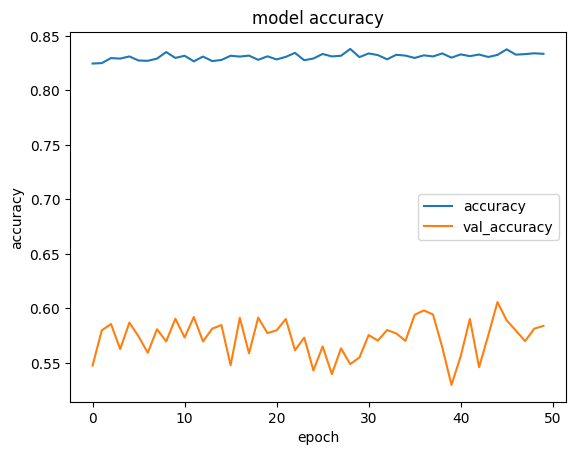

In [226]:
# summarize history for accuracy
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

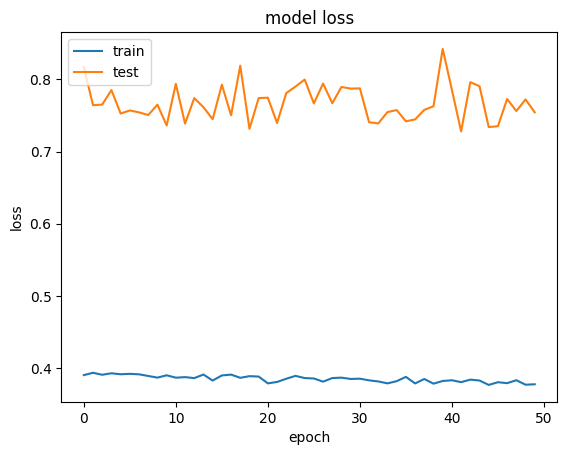

In [227]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [228]:
#Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [229]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1878,  125],
       [ 223,  274]])

In [230]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.8608

In [231]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      2003
           1       0.69      0.55      0.61       497

    accuracy                           0.86      2500
   macro avg       0.79      0.74      0.76      2500
weighted avg       0.85      0.86      0.85      2500

